## 15. Explainability (XAI) - SHAP----------------------------------------------

In [ ]:
# Install SHAP if not already installed
import shap

# Use a sample of the test set for SHAP computations (faster on large datasets)
# 500 samples is sufficient to capture global patterns
X_shap_sample = X_test.sample(500, random_state=42)

print(f"Computing SHAP values for: {best_model_name}")
print(f"Sample size: {X_shap_sample.shape[0]} rows")

Computing SHAP values for: SMOTE + Random Forest
Sample size: 500 rows


In [ ]:
# Transform the sample through the preprocessing pipeline
# SHAP works on the raw feature space, so we extract the preprocessed array and get the classifier step separately

# Get the preprocessed feature matrix
# We need to apply the same preprocessing the model uses
if hasattr(best_est, 'named_steps'):
    # Get the step names from the pipeline
    step_names = list(best_est.named_steps.keys())
    prep_step  = step_names[0]   # first step is always preprocessing
    clf_step   = step_names[-1]  # last step is always the classifier

    # Transform the SHAP sample through the preprocessing step only
    X_shap_transformed = best_est.named_steps[prep_step].transform(X_shap_sample)
    clf_model = best_est.named_steps[clf_step]
else:
    # Fallback if model is not a pipeline
    X_shap_transformed = X_shap_sample.values
    clf_model = best_est

# Get feature names after preprocessing
feature_names = list(X_shap_sample.columns)

print(f"Preprocessed shape: {X_shap_transformed.shape}")
print("Feature names ready.")

Preprocessed shape: (500, 54)
Feature names ready.


In [ ]:
# Create a SHAP TreeExplainer to optimize for tree-based models (RF, XGB, LightGBM)
# TreeExplainer is exact (not approximate) for tree models and very fast
explainer = shap.TreeExplainer(clf_model)

# Compute SHAP values for all samples and all classes
# shap_values shape (n_samples, n_features, n_classes)
shap_values = explainer.shap_values(X_shap_transformed)

print("SHAP values computed successfully.")
if isinstance(shap_values, list):
    print(f"Number of classes: {len(shap_values)}")
    print(f"Shape per class  : {shap_values[0].shape}")
else:
    print(f"SHAP values shape: {shap_values.shape}")

SHAP values computed successfully.
SHAP values shape: (500, 54, 7)


# SHAP SUMMARY PLOT (BEESWARM)

<Figure size 640x480 with 0 Axes>

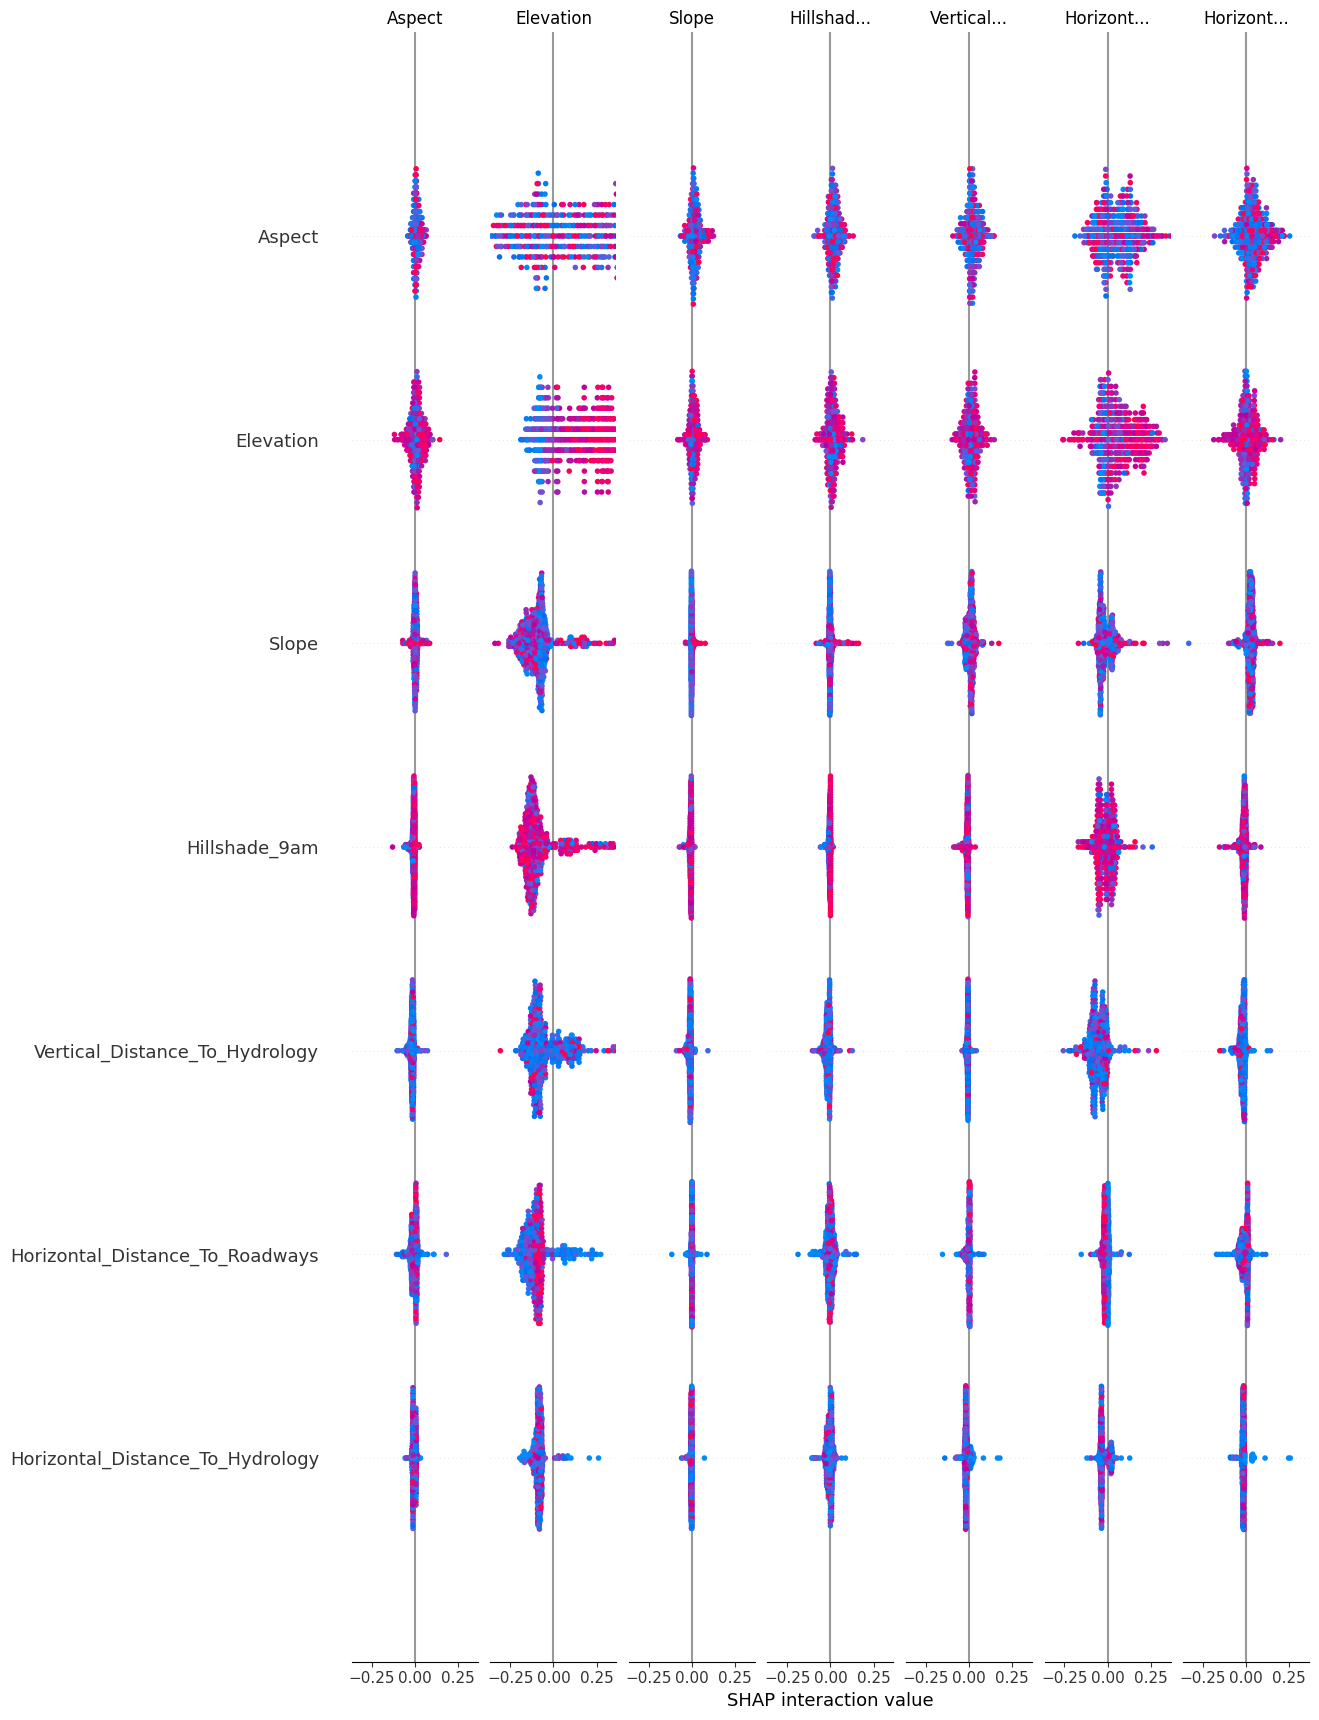

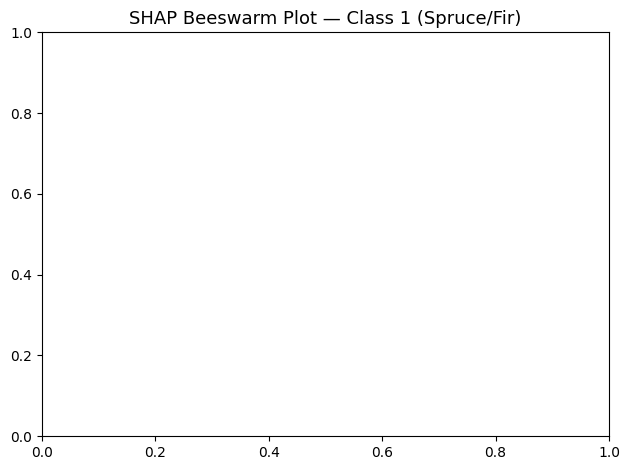

In [ ]:
# SHAP Summary with Beeswarm Plot (the most informative SHAP visualization)
# this plot will show BOTH which features matter AND the direction of their effect

# For multiclass, we show the summary across all classes combined
# If shap_values is a list (one array per class) then stack and take mean absolute
if isinstance(shap_values, list):
    # Stack all class SHAP values shape (n_classes, n_samples, n_features)
    shap_all_classes = np.array(shap_values)  # (n_classes, n_samples, n_features)
    # Use class 0 for the beeswarm (Spruce/Fir) as a representative example
    shap_class0 = shap_values[0]
else:
    shap_class0 = shap_values

plt.figure()
shap.summary_plot(
    shap_class0,
    X_shap_transformed,
    feature_names=feature_names,
    plot_type='dot',        # beeswarm style
    max_display=20,         # show top 20 features
    show=True
)
plt.title('SHAP Beeswarm Plot \u2014 Class 1 (Spruce/Fir)', fontsize=13)
plt.tight_layout()
plt.show()

SHAP BAR PLOT

In [ ]:
# SHAP Global Bar Plot  (shows mean absolute SHAP value per feature)
# cleanest way to present global feature importance in a report, higher bar means that feature contributes more on average to any prediction

if isinstance(shap_values, list):
    # For multiclass, average absolute SHAP values across all classes
    mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
else:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create a sorted DataFrame for plotting
shap_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(shap_importance_df['Feature'], shap_importance_df['Mean |SHAP|'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Mean |SHAP Value| (Average Impact on Model Output)')
plt.title(f'SHAP Global Feature Importance \u2014 {best_model_name}')
plt.tight_layout()
plt.show()

print("Top 10 features by mean absolute SHAP value:")
print(shap_importance_df.head(10).to_string(index=False))

ValueError: Per-column arrays must each be 1-dimensional

SHAP WATERFALL PLOT

In [ ]:
# SHAP Waterfall Plot (explains a SINGLE prediction (local explanation))
# shows how each feature pushes the prediction higher (red) or lower (blue) by starting from the base value (expected model output) to the final prediction
# powerful for showing the professor you understand individual decisions

# Pick one sample to explain with index 0 of our SHAP sample
sample_idx = 0

if isinstance(shap_values, list):
    # Use class 0 (Spruce/Fir) as the example class to explain
    explain_class = 0
    shap_explanation = shap.Explanation(
        values=shap_values[explain_class][sample_idx],
        base_values=explainer.expected_value[explain_class],
        data=X_shap_transformed[sample_idx],
        feature_names=feature_names
    )
else:
    shap_explanation = shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_shap_transformed[sample_idx],
        feature_names=feature_names
    )

# Plot waterfall by red bars push prediction up, blue bars push it down
plt.figure(figsize=(10, 7))
shap.plots.waterfall(shap_explanation, max_display=15, show=True)
plt.title(f'SHAP Waterfall \u2014 Single Sample Explanation (Class 1: Spruce/Fir)', fontsize=12)
plt.tight_layout()
plt.show()

SHAP DECISION PLOT

In [ ]:
# SHAP Decision Plot (shows how features cumulatively push predictions)
# for multiple samples at once (local explanation for a group)
# lines diverging early means those features are most decisive

# select a small group of samples to visualize (5 samples for clarity)
n_display = 5

if isinstance(shap_values, list):
    # Use class 0 (Spruce/Fir) for the decision plot
    explain_class = 0
    shap_vals_display  = shap_values[explain_class][:n_display]
    expected_val       = explainer.expected_value[explain_class]
else:
    shap_vals_display  = shap_values[:n_display]
    expected_val       = explainer.expected_value

plt.figure(figsize=(10, 8))
shap.decision_plot(
    expected_val,
    shap_vals_display,
    feature_names=feature_names,
    feature_display_range=slice(None, -20, -1),  # show top 20 features
    show=True
)
plt.title(f'SHAP Decision Plot \u2014 5 Samples (Class 1: Spruce/Fir)', fontsize=12)
plt.tight_layout()
plt.show()

SHAP INTERPRETATION Conclusion:

XAI Interpretation using SHAP:

SHAP (SHapley Additive exPlanations) provides both global and local explanations for the best model's predictions. Key findings:

Global Explanation (Bar Plot and Beeswarm):
- Elevation is typically the most impactful feature — higher elevations strongly favor Spruce/Fir (Class 1) while lower elevations favor Ponderosa Pine (Class 3).
- Horizontal_Distance_To_Roadways and Horizontal_Distance_To_Hydrology reveal how tree species distribution is tied to human infrastructure and water access.
- Wilderness_Area dummy variables have high SHAP values — confirming that geographic zone is a strong predictor of which tree type dominates.

Local Explanation (Waterfall Plot):
- The waterfall plot shows how each feature pushed a single prediction away from the base value (average model output).
- Red bars increase the predicted probability of that class; blue bars decrease it.
- This lets us explain any individual prediction in plain language for a report or presentation.

Decision Plot:
- Multiple samples are shown simultaneously, revealing that most samples follow similar feature pathways — giving confidence that the model has learned consistent patterns rather than memorizing noise.